In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import the necessary packages
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from collections import Counter

In [3]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large, VGG16
from tensorflow.keras.applications import EfficientNetV2B0, ConvNeXtSmall, DenseNet121,ResNet50,InceptionV3,EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D,Flatten,Dropout
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.applications.mobilenet import preprocess_input as mob_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input
from tensorflow.keras.applications.convnext import preprocess_input as conv_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input

2025-05-10 13:56:05.919169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746885366.108903      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746885366.163958      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
import tensorflow as tf

# Check available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs are available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPUs detected.")

GPUs are available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
#read label information
df = pd.read_csv('/kaggle/input/deepweeds/labels.csv')
df.head()

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


In [6]:
df[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [7]:
label2id = df[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [8]:
num_classes = len(df['Label'].unique())
num_classes

9

In [9]:
df1=df[['Filename','Label']]
df1['Label']=df['Label'].astype(int)
df1['Species'] = df1['Label'].map(id2label)
df1.head()

/tmp/ipykernel_19/2892309576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Label']=df['Label'].astype(int)


,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


In [10]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df1, test_size=0.3, shuffle=True, random_state=23, stratify=df['Label'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
len(train), len(test)


(12256, 5253)

In [11]:
df1['Species'].value_counts()

Species
Negative          9106
Chinee apple      1125
Siam weed         1074
Lantana           1064
Prickly acacia    1062
Parkinsonia       1031
Parthenium        1022
Snake weed        1016
Rubber vine       1009
Name: count, dtype: int64

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Set validation split
)

In [13]:
image_size = (256, 256)  # Change based on your model's requirements
batch_size = 64

In [14]:
img_dir='/kaggle/input/deepweeds/images'

In [15]:
# Train Data Generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use subset for training
)

Found 9805 validated image filenames belonging to 9 classes.


In [16]:
print("Class indices:", train_generator.class_indices)

Class indices: {'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8}


In [17]:
# Validation Data Generator
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use subset for validation
)

Found 2451 validated image filenames belonging to 9 classes.


In [18]:
print("Class indices:", validation_generator.class_indices)

Class indices: {'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8}


In [19]:
# Create ImageDataGenerator for test (no augmentation)
test_datagen = ImageDataGenerator(
    rescale=1./255
    )

In [20]:
# Test Data Generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',  # Assuming test data might still have labels, if not, use None
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',  # Use 'None' if no labels are available
    shuffle=False  # Important for test data to maintain order
)

Found 5253 validated image filenames belonging to 9 classes.


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K
# Step 1: Define the Channel Attention Module (CAM)
def channel_attention(input_feature, ratio=8):
    channel_axis = -1
    channels = input_feature.shape[channel_axis]

    # Shared MLP (Multi-Layer Perceptron)
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channels))(avg_pool)
    avg_pool = layers.Dense(channels // ratio, activation='relu')(avg_pool)
    avg_pool = layers.Dense(channels, activation='sigmoid')(avg_pool)
    
    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channels))(max_pool)
    max_pool = layers.Dense(channels // ratio, activation='relu')(max_pool)
    max_pool = layers.Dense(channels, activation='sigmoid')(max_pool)

    # Combine the average and max pooling attention
    channel_attention_map = layers.Add()([avg_pool, max_pool])
    channel_attention_map = layers.Multiply()([input_feature, channel_attention_map])
    
    return channel_attention_map

# Step 2: Define the Spatial Attention Module (SAM)
def spatial_attention(input_feature):
    kernel_size = 7
    avg_pool = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_feature)
    
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention_map = layers.Conv2D(filters=1, kernel_size=kernel_size, strides=1, padding='same', activation='sigmoid')(concat)
    spatial_attention_map = layers.Multiply()([input_feature, spatial_attention_map])
    
    return spatial_attention_map

In [22]:
from tensorflow.keras.layers import SeparableConv2D,BatchNormalization,ReLU,Concatenate, Reshape
def atrous_block(input_tensor, filters):
    """
    Atrous convolution block with multiple dilation rates.
    """
    conv_1 = SeparableConv2D(filters, kernel_size=3, dilation_rate=6, padding='same', activation='relu')(input_tensor)
    conv_1 = BatchNormalization()(conv_1)
    conv_1 = ReLU()(conv_1)
    
    conv_2 = SeparableConv2D(filters, kernel_size=3, dilation_rate=12, padding='same', activation='relu')(input_tensor)
    conv_2 = BatchNormalization()(conv_2)
    conv_2 = ReLU()(conv_2)
    
    conv_3 = SeparableConv2D(filters, kernel_size=3, dilation_rate=18, padding='same', activation='relu')(input_tensor)
    conv_3 = BatchNormalization()(conv_3)
    conv_3 = ReLU()(conv_2)

    # Concatenate all the dilated features
    concat = Concatenate(axis=-1)([conv_1, conv_2, conv_3])
    return concat

In [23]:
# CBAM Block with Atrous Convolution (Dilated Convolution)
def cbam(input_feature, ratio=8):
    # Apply Channel Attention with Atrous Convolution
    channel_att = channel_attention(input_feature, ratio)
    
    # Apply Spatial Attention with Atrous Convolution
    spatial_att = spatial_attention(channel_att)
    
    return spatial_att

In [24]:
# --- EfficientNet + Atrous Convolution + CBAM ---
def build_base_model(input_shape):
    base_model = EfficientNetV2B0(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False
    model = models.Model(inputs=base_model.input, outputs=base_model.output)
    return model


In [25]:
def build_model(base_model, num_classes):
    x = base_model.output
    
    # Apply Atrous Convolution
    atrous_features = atrous_block(x, filters=256)
    
    # Apply CBAM
    refined_features = cbam(atrous_features)
    
    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(refined_features)
    
    # Fully connected layers for classification
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)  # Assuming binary classification (weed vs crop)
    
    model = models.Model(inputs=base_model.input, outputs=output)
    
    return model

In [26]:
from tensorflow.keras import backend as K
from tensorflow.keras.layers import GlobalMaxPooling2D,Add,Activation,Multiply
base_model=build_base_model(image_size +(3,))
model = build_model(base_model,num_classes)

I0000 00:00:1746885421.327169      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
#model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#model.summary()

In [28]:
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
# Constant for epochs
EPOCHS = 40

pat_es = 5
early_stopping = EarlyStopping(monitor='val_loss', patience=pat_es, verbose=1, restore_best_weights=True)
reduce_lr =ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=3, verbose=1, min_lr=1e-6)

model.compile(loss='categorical_crossentropy',
          optimizer= AdamW(learning_rate=2e-4,  weight_decay=5e-2),
          metrics=['accuracy'])

In [29]:
# Define your folder to save results
import os
save_folder = model.name
os.makedirs(save_folder, exist_ok=True)

In [30]:
filename= model.name+'.h5'
model_weight= os.path.join(save_folder, filename)
model_weight

'functional_1/functional_1.h5'

In [31]:
%%time
# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr],
    )

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746885457.926084      59 service.cc:148] XLA service 0x7e87d00048d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746885457.926805      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746885460.555063      59 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1746885466.440651      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746885466.755328      59 gpu_timer.cc:

  2/154 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0820 - loss: 2.1980   

I0000 00:00:1746885477.638152      59 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 25/154 ━━━━━━━━━━━━━━━━━━━━ 2:22 1s/step - accuracy: 0.3944 - loss: 2.1200

E0000 00:00:1746885510.967811      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746885511.197902      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746885511.554380      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746885511.778858      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746885512.197099      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4875 - loss: 1.8906

E0000 00:00:1746885720.118712      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746885720.353228      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


154/154 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.4877 - loss: 1.8900 - val_accuracy: 0.5308 - val_loss: 2.0470 - learning_rate: 2.0000e-04
Epoch 2/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.5202 - loss: 1.7143 - val_accuracy: 0.5308 - val_loss: 1.9927 - learning_rate: 2.0000e-04
Epoch 3/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.5156 - loss: 1.7142 - val_accuracy: 0.5308 - val_loss: 1.8481 - learning_rate: 2.0000e-04
Epoch 4/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5210 - loss: 1.7006 - val_accuracy: 0.5308 - val_loss: 1.7362 - learning_rate: 2.0000e-04
Epoch 5/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.5131 - loss: 1.7035 - val_accuracy: 0.5308 - val_loss: 1.6481 - learning_rate: 2.0000e-04
Epoch 6/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.5093 - loss: 1.7015 - val_accuracy: 0.5308 - val_loss: 1.6334 - learning_rate: 2.0000e-04
Epoch 7/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.51

In [32]:
print("Saving the Model")
model.save(model_weight)

Saving the Model


In [33]:
#image visualization
import matplotlib.pyplot as plt
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()
    plt.savefig(os.path.join(save_folder, 'training_chart.png'))
    plt.show()

Total Epochs: range(0, 24)


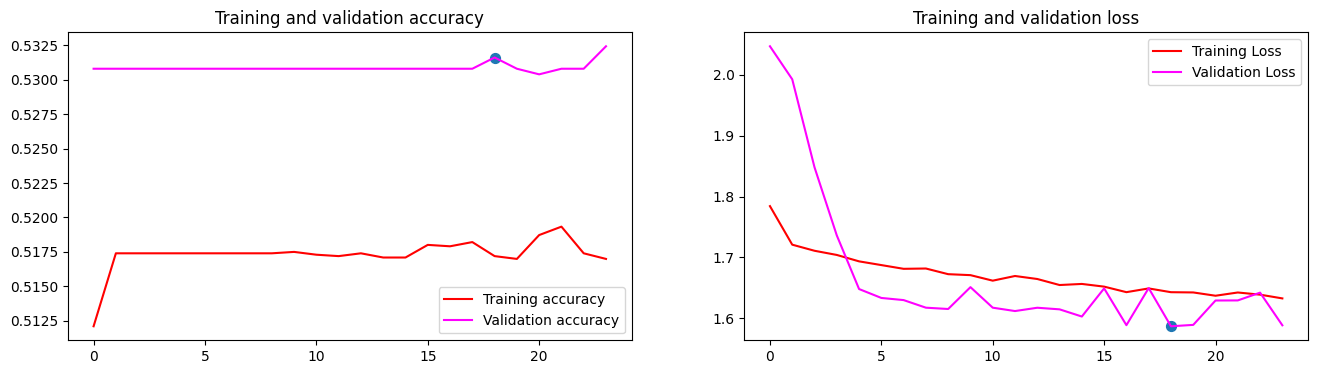

In [34]:
# Plot training results
plot_loss_acc(history1.history)

In [35]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [36]:
predictions=model.predict(test_generator)

82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step

E0000 00:00:1746889961.368636      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746889961.592277      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


83/83 ━━━━━━━━━━━━━━━━━━━━ 58s 623ms/step


In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)
# Get true labels from the test generator
true_labels = test_generator.classes
# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[  10    0  327    0    0    0    0    0    0]
 [   0    0  319    0    0    0    0    0    0]
 [   1    0 2731    0    0    0    0    0    0]
 [   0    0  309    0    0    0    0    0    0]
 [   0    0  307    0    0    0    0    0    0]
 [   1    0  318    0    0    0    0    0    0]
 [   1    0  302    0    0    0    0    0    0]
 [   0    0  322    0    0    0    0    0    0]
 [   9    0  296    0    0    0    0    0    0]]


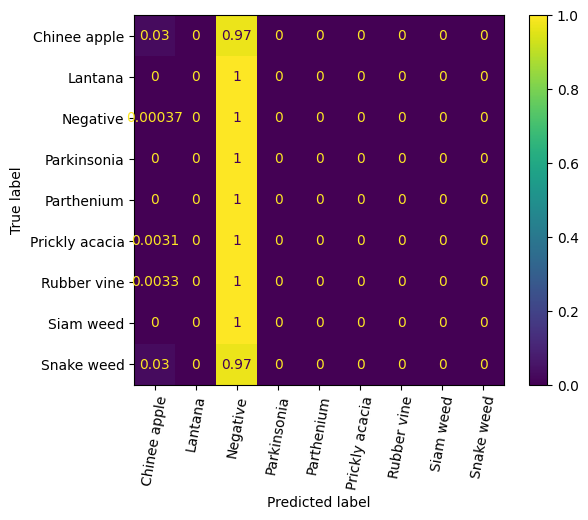

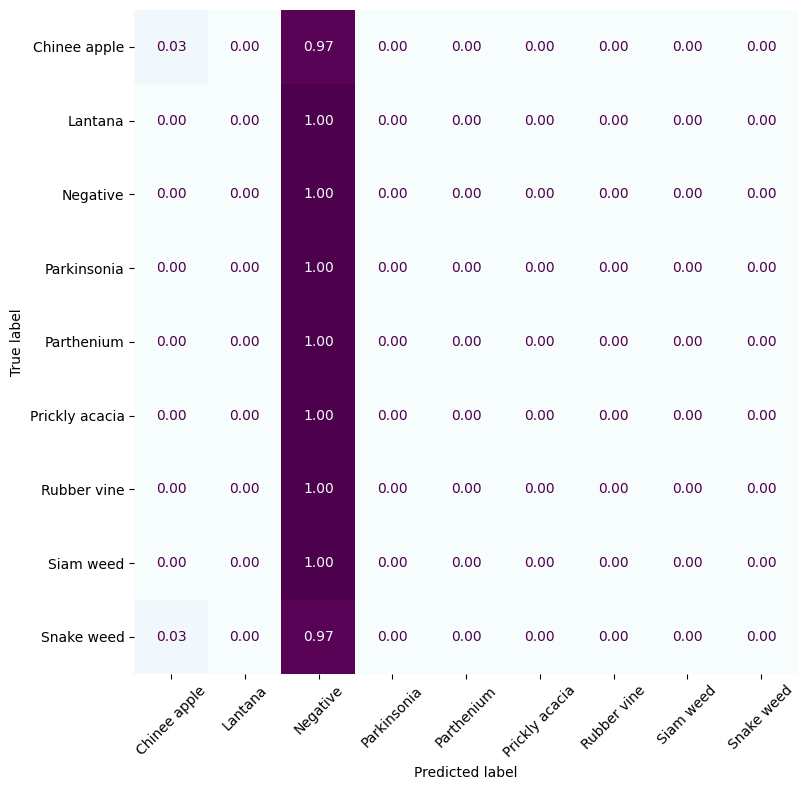

In [38]:
cmd = ConfusionMatrixDisplay.from_predictions(
        true_labels, predicted_classes,
        display_labels=list(test_generator.class_indices.keys()),
        xticks_rotation=80, #'vertical',
        normalize='true'
        # ax = ax
    )
    # fig, ax = plt.subplots(figsize=(25,5))
    # cmd.plot(ax=ax)
fig, ax = plt.subplots(figsize=(10, 8))
           # Remove axis spines (frame)
for spine in ax.spines.values():
        spine.set_visible(False)
cmd.plot(ax=ax, cmap='BuPu', xticks_rotation=45,  values_format='.2f', colorbar=False)
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'confusion-mat.png'))
plt.show()